In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

In [ ]:
df = pd.read_csv('/content/spam_email_dataset.csv')
df.head()

,email_id,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label
0,0,Weekly Report,budget review - Statement our I claim world st...,19,114,0,2,0,2,1,lctvdzm@outlook.com,outlook.com,0.66,19,3,0,23,0,0,0
1,1,Project Update,team sync - President series today already. In...,18,114,0,7,0,0,0,pxyldmi@company.com,company.com,0.95,4,4,0,16,1,0,0
2,2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,19,126,0,4,1,1,1,atvanls@unknownmail.cc,unknownmail.cc,0.68,3,0,0,10,1,1,1
3,3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,16,101,0,7,1,1,1,qalxcnf@chealdealz.xyz,chealdealz.xyz,0.69,19,5,1,25,1,1,1
4,4,Meeting Reminder,team sync - Significant property hotel not add...,18,111,0,7,1,2,1,xoiccxl@yahoo.com,yahoo.com,0.67,4,5,1,8,0,0,0


In [ ]:
df.shape

(10000, 20)

In [ ]:

df.info

<bound method DataFrame.info of       email_id                subject  \
0            0          Weekly Report   
1            1         Project Update   
2            2         🔥WIN BIG NOW!!   
3            3         🔥WIN BIG NOW!!   
4            4       Meeting Reminder   
...        ...                    ...   
9995      9995         🔥WIN BIG NOW!!   
9996      9996    You are selected!!!   
9997      9997    You are selected!!!   
9998      9998       Meeting Reminder   
9999      9999  Schedule Confirmation   

                                             email_text  num_words  \
0     budget review - Statement our I claim world st...         19   
1     team sync - President series today already. In...         18   
2     win free urgent offer limited limited urgent u...         19   
3     guarantee click now cash offer click now guara...         16   
4     team sync - Significant property hotel not add...         18   
...                                                 ...        ...   
9995  free win cash win guarantee urgent free win li...         22   
9996  click now free guarantee free win click now wi...         26   
9997  offer cash win limited click now cash limited ...         21   
9998           budget review - Many result affect idea.          7   
9999  budget review - Day measure few alone decade a...         15   

      num_characters  num_exclamation_marks  num_links  has_suspicious_link  \
0                114                      0          2                    0   
1                114                      0          7                    0   
2                126                      0          4                    1   
3                101                      0          7                    1   
4                111                      0          7                    1   
...              ...                    ...        ...                  ...   
9995             136                      0          5                    1   
9996             158                      0          2                    0   
9997             124                      0          3                    1   
9998              40                      0          1                    0   
9999              86                      0          3                    0   

      num_attachments  has_attachment            sender_email   sender_domain  \
0                   2               1     lctvdzm@outlook.com     outlook.com   
1                   0               0     pxyldmi@company.com     company.com   
2                   1               1  atvanls@unknownmail.cc  unknownmail.cc   
3                   1               1  qalxcnf@chealdealz.xyz  chealdealz.xyz   
4                   2               1       xoiccxl@yahoo.com       yahoo.com   
...               ...             ...                     ...             ...   
9995                0               0  fefsrcz@unknownmail.cc  unknownmail.cc   
9996                0               0  yxyctux@chealdealz.xyz  chealdealz.xyz   
9997                1               1  tkvqnki@unknownmail.cc  unknownmail.cc   
9998                2               1     wmvnrbn@outlook.com     outlook.com   
9999                1               1       tpydjum@gmail.com       gmail.com   

      sender_reputation_score  email_hour  email_day_of_week  is_weekend  \
0                        0.66          19                  3           0   
1                        0.95           4                  4           0   
2                        0.68           3                  0           0   
3                        0.69          19                  5           1   
4                        0.67           4                  5           1   
...                       ...         ...                ...         ...   
9995                     0.68           8                  1           0   
9996                     0.76           2                  3           0   
9997                     0.6

In [ ]:
#feature selection
features=['num_words','num_links','num_exclamation_marks','sender_reputation_score','num_recipients','contains_money_terms','contains_urgency_terms']
x= df[features]
y= df['label']

In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)


In [ ]:
lr= LogisticRegression()
lr.fit(x_train, y_train)
pred_lr= lr.predict(x_test)
print("Lr accuracy:", accuracy_score(y_test, pred_lr))

Lr accuracy: 0.847


In [ ]:
dt= DecisionTreeClassifier()
dt.fit(x_train, y_train)
pred_dt= dt.predict(x_test)

In [ ]:
nb= MultinomialNB()
nb.fit(x_train, y_train)
pred_nb= nb.predict(x_test)

In [ ]:
knn= KNeighborsClassifier()
knn.fit(x_train, y_train)
pred_knn= knn.predict(x_test)

In [ ]:
rf= RandomForestClassifier()
rf.fit(x_train, y_train)
pred_rf= rf.predict(x_test)
print("Rf accuracy:", accuracy_score(y_test, pred_rf))


Rf accuracy: 0.8595


In [ ]:
print("Logistic Regression Classification Report:", classification_report(y_test, pred_lr))
print("Random Forest Classification Report:", classification_report(y_test, pred_rf))
print("Decision tree classification report: ", classification_report(y_test, pred_dt))
print("KNN classification report: ", classification_report(y_test, pred_knn))
print("Naive Bayes classification report: ", classification_report(y_test, pred_nb))


Logistic Regression Classification Report:               precision    recall  f1-score   support

           0       0.86      0.88      0.87      1181
           1       0.83      0.79      0.81       819

    accuracy                           0.85      2000
   macro avg       0.84      0.84      0.84      2000
weighted avg       0.85      0.85      0.85      2000

Random Forest Classification Report:               precision    recall  f1-score   support

           0       0.87      0.89      0.88      1181
           1       0.84      0.81      0.83       819

    accuracy                           0.86      2000
   macro avg       0.86      0.85      0.85      2000
weighted avg       0.86      0.86      0.86      2000

Decision tree classification report:                precision    recall  f1-score   support

           0       0.85      0.85      0.85      1181
           1       0.78      0.79      0.78       819

    accuracy                           0.82      2000
   macro a

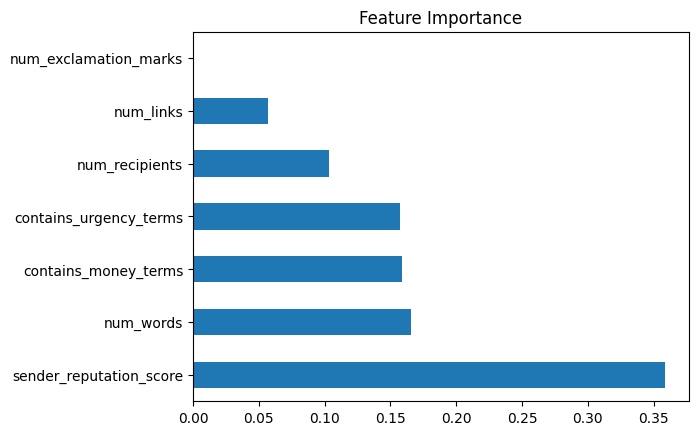

In [ ]:
#feature importance of rf
importance= pd.Series(rf.feature_importances_,index= features)
importance.sort_values(ascending=False).plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [ ]:
rf.fit(x_train, y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import log_loss

#classification metrics
eval_models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "K-Nearest Neighbors": knn,
    "Random Forest": rf,
    "Naive Bayes": nb
}

metric_results = {}

for name, model in eval_models.items():
    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    metric_results[name] = {"y_pred": y_pred, "y_prob": y_prob}


    print(f"  {name}")
    print(f"  Accuracy        : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision       : {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall          : {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score        : {f1_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC         : {roc_auc_score(y_test, y_prob):.4f}")
    print(f"  Log Loss        : {log_loss(y_test, y_prob):.4f}")

  Logistic Regression
  Accuracy        : 0.8470
  Precision       : 0.8251
  Recall          : 0.7949
  F1-Score        : 0.8097
  ROC-AUC         : 0.9293
  Log Loss        : 0.3318
  Decision Tree
  Accuracy        : 0.8225
  Precision       : 0.7809
  Recall          : 0.7875
  F1-Score        : 0.7842
  ROC-AUC         : 0.8171
  Log Loss        : 6.3981
  K-Nearest Neighbors
  Accuracy        : 0.7910
  Precision       : 0.7587
  Recall          : 0.7179
  F1-Score        : 0.7378
  ROC-AUC         : 0.8564
  Log Loss        : 1.4012
  Random Forest
  Accuracy        : 0.8595
  Precision       : 0.8346
  Recall          : 0.8193
  F1-Score        : 0.8269
  ROC-AUC         : 0.9376
  Log Loss        : 0.3897
  Naive Bayes
  Accuracy        : 0.6860
  Precision       : 0.6201
  Recall          : 0.6020
  F1-Score        : 0.6109
  ROC-AUC         : 0.7572
  Log Loss        : 0.5891


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, brier_score_loss
#regression metrics
for name, res in metric_results.items():
    y_prob = res["y_prob"]
    mse    = mean_squared_error(y_test, y_prob)
    rmse   = np.sqrt(mse)
    mae    = mean_absolute_error(y_test, y_prob)
    brier  = brier_score_loss(y_test, y_prob)

    print(f"\n  {name}")
    print(f"  MSE          : {mse:.4f}   ← avg squared error of prob vs true label")
    print(f"  RMSE         : {rmse:.4f}  ← same scale as probability (0–1)")
    print(f"  MAE          : {mae:.4f}   ← avg absolute error of prob vs true label")
    print(f"  Brier Score  : {brier:.4f} ← primary calibration metric (lower = better)")


  Logistic Regression
  MSE          : 0.1043   ← avg squared error of prob vs true label
  RMSE         : 0.3229  ← same scale as probability (0–1)
  MAE          : 0.2044   ← avg absolute error of prob vs true label
  Brier Score  : 0.1043 ← primary calibration metric (lower = better)

  Decision Tree
  MSE          : 0.1776   ← avg squared error of prob vs true label
  RMSE         : 0.4215  ← same scale as probability (0–1)
  MAE          : 0.1777   ← avg absolute error of prob vs true label
  Brier Score  : 0.1776 ← primary calibration metric (lower = better)

  K-Nearest Neighbors
  MSE          : 0.1499   ← avg squared error of prob vs true label
  RMSE         : 0.3872  ← same scale as probability (0–1)
  MAE          : 0.2711   ← avg absolute error of prob vs true label
  Brier Score  : 0.1499 ← primary calibration metric (lower = better)

  Random Forest
  MSE          : 0.0959   ← avg squared error of prob vs true label
  RMSE         : 0.3096  ← same scale as probability (

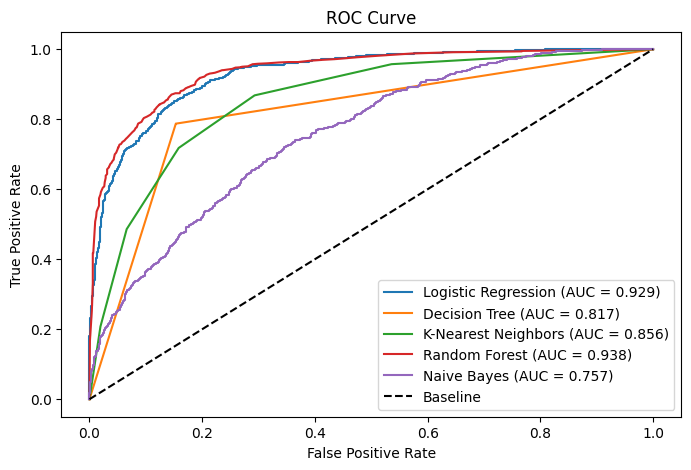

In [ ]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8, 5))
for name, res in metric_results.items():
    fpr_c, tpr_c, _ = roc_curve(y_test, res["y_prob"])
    roc_auc_val      = auc(fpr_c, tpr_c)
    plt.plot(fpr_c, tpr_c, label=f"{name} (AUC = {roc_auc_val:.3f})")
plt.plot([0, 1], [0, 1], 'k--', label='Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png", dpi=150)
plt.show(

)

In [ ]:

for name, res in metric_results.items():
    y_pred = res["y_pred"]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    specificity  = tn / (tn + fp)
    fpr_val      = fp / (fp + tn)
    fnr_val      = fn / (fn + tp)
    balanced_acc = (recall_score(y_test, y_pred) + specificity) / 2

    print(f"\n  {name}")
    print(f"  TP (Spam caught)          : {tp}")
    print(f"  TN (Ham correctly passed) : {tn}")
    print(f"  FP (Ham flagged as spam)  : {fp}")
    print(f"  FN (Spam missed)          : {fn}")
    print(f"  Specificity               : {specificity:.4f}")
    print(f"  False Positive Rate       : {fpr_val:.4f}")
    print(f"  False Negative Rate       : {fnr_val:.4f}")
    print(f"  Balanced Accuracy         : {balanced_acc:.4f}")


  Logistic Regression
  TP (Spam caught)          : 651
  TN (Ham correctly passed) : 1043
  FP (Ham flagged as spam)  : 138
  FN (Spam missed)          : 168
  Specificity               : 0.8831
  False Positive Rate       : 0.1169
  False Negative Rate       : 0.2051
  Balanced Accuracy         : 0.8390

  Decision Tree
  TP (Spam caught)          : 645
  TN (Ham correctly passed) : 1000
  FP (Ham flagged as spam)  : 181
  FN (Spam missed)          : 174
  Specificity               : 0.8467
  False Positive Rate       : 0.1533
  False Negative Rate       : 0.2125
  Balanced Accuracy         : 0.8171

  K-Nearest Neighbors
  TP (Spam caught)          : 588
  TN (Ham correctly passed) : 994
  FP (Ham flagged as spam)  : 187
  FN (Spam missed)          : 231
  Specificity               : 0.8417
  False Positive Rate       : 0.1583
  False Negative Rate       : 0.2821
  Balanced Accuracy         : 0.7798

  Random Forest
  TP (Spam caught)          : 671
  TN (Ham correctly passed) : 10

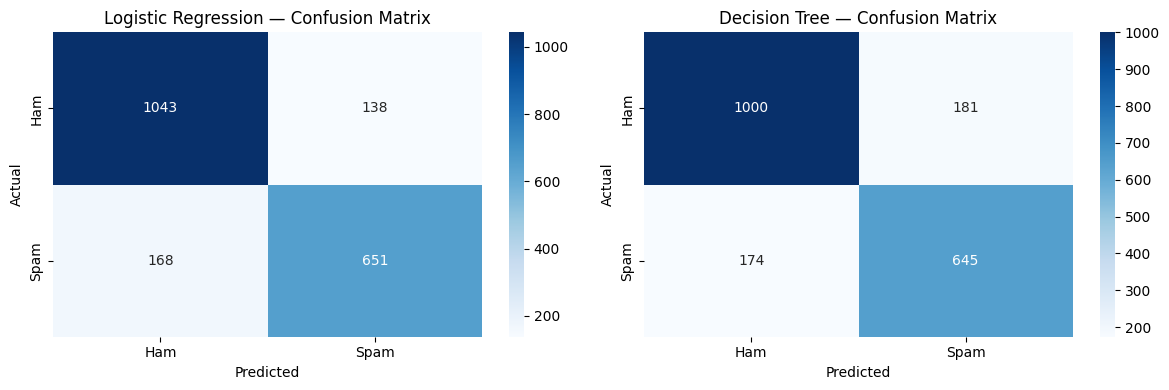

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, res) in zip(axes, metric_results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'],
                yticklabels=['Ham', 'Spam'])
    ax.set_title(f"{name} — Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150)
plt.show()


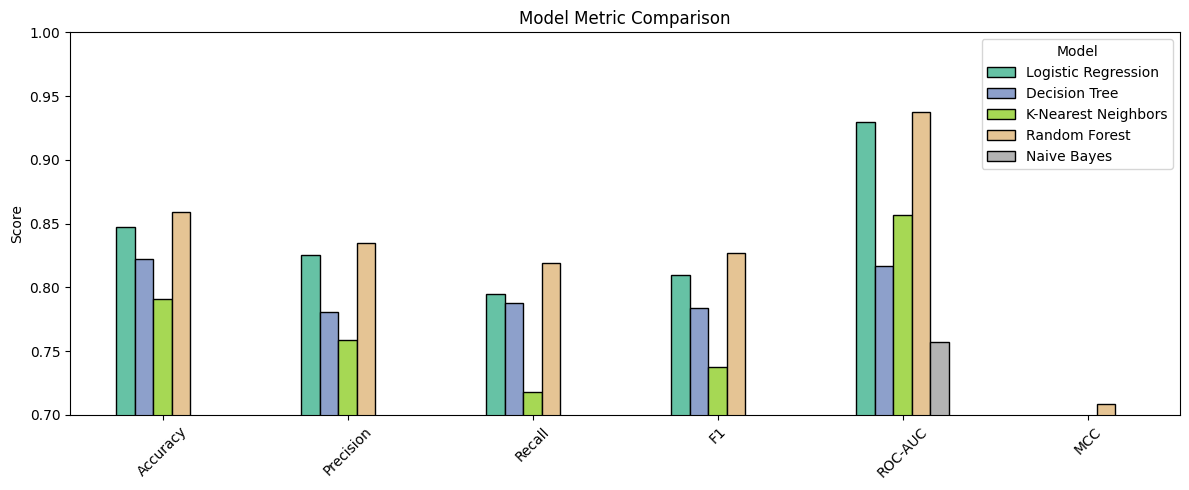

In [ ]:
from sklearn.metrics import matthews_corrcoef

# Prepare data for summary_df
summary_data = {}
for name, res in metric_results.items():
    y_pred = res["y_pred"]
    y_prob = res["y_prob"]
    summary_data[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred)
    }

# Create summary_df
summary_df = pd.DataFrame.from_dict(summary_data, orient='index')

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "MCC"]
summary_df[metrics_to_plot].T.plot(
    kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black'
)
plt.title("Model Metric Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.ylim(0.7, 1.0)
plt.legend(title="Model")
plt.tight_layout()
plt.savefig("metric_comparison.png", dpi=150)
plt.show()